In [ ]:
import nltk

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words('english')
# sw=stopwords.words('chinese')

sw
#print(len(sw))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
s='the sun rise in the east'

from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
tokens=word_tokenize(s)

tokens

# a=s.split()
# a

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['the', 'sun', 'rise', 'in', 'the', 'east']

In [ ]:
from nltk.util import ngrams

ng=ngrams(sequence=tokens,n=2)

list(ng)

[('the', 'sun'),
 ('sun', 'rise'),
 ('rise', 'in'),
 ('in', 'the'),
 ('the', 'east')]

In [ ]:
s='this is a sample sentence for stopword removal'

# wap to find the words which has length greater than 4
l=[]
tokens=word_tokenize(s)
for i in tokens:
  if len(i)>4:
    l.append(i)
print(l)

['sample', 'sentence', 'stopword', 'removal']


In [ ]:
# wap to remove stopwords from a given sentence

s='this is a sample sentence for stopword removal'
a=s.split()
l=[i for i in a if i.lower() not in sw]
l

['sample', 'sentence', 'stopword', 'removal']

In [ ]:
# stemming :porterstemmer english, snowball stemmer: other language

In [ ]:
from nltk.stem import PorterStemmer

ps=PorterStemmer()
ps.stem('eating')

'eat'

In [ ]:
l=['eating','jumping','running']
l1=[ps.stem(i) for i in l]
l1

['eat', 'jump', 'run']

In [ ]:
from nltk.stem import SnowballStemmer
sn=SnowballStemmer('english')
sn.stem('eating')

'eat'

In [ ]:
l=['flying','crying','jumped']
l1=[sn.stem(i) for i in l]
l1

['fli', 'cri', 'jump']

In [ ]:
# lemmatization

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wn=WordNetLemmatizer()

wn.lemmatize('caring',pos='v')

[nltk_data] Downloading package wordnet to /root/nltk_data...


'care'

In [ ]:
l=['dreaming','running','jumped','ate']

l1=[wn.lemmatize(i,pos='v') for i in l]
l1

['dream', 'run', 'jump', 'eat']

In [ ]:
s=['earth is the third planet from the sun','jupiter is the largest planet']

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

y=tfidf.fit_transform(s)

print(y)

print(tfidf.get_feature_names_out())
v=tfidf.get_feature_names_out()
print(y.toarray())

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (2, 9)>
  Coords	Values
  (0, 0)	0.37695708675831013
  (0, 2)	0.2682080718928097
  (0, 7)	0.5364161437856194
  (0, 8)	0.37695708675831013
  (0, 5)	0.2682080718928097
  (0, 1)	0.37695708675831013
  (0, 6)	0.37695708675831013
  (1, 2)	0.3793034928087496
  (1, 7)	0.3793034928087496
  (1, 5)	0.3793034928087496
  (1, 3)	0.5330978245262535
  (1, 4)	0.5330978245262535
['earth' 'from' 'is' 'jupiter' 'largest' 'planet' 'sun' 'the' 'third']
[[0.37695709 0.37695709 0.26820807 0.         0.         0.26820807
  0.37695709 0.53641614 0.37695709]
 [0.         0.         0.37930349 0.53309782 0.53309782 0.37930349
  0.         0.37930349 0.        ]]


In [ ]:
import pandas as pd

df=pd.DataFrame(y.toarray(),columns=v)

df

,earth,from,is,jupiter,largest,planet,sun,the,third
0,0.376957,0.376957,0.268208,0.000000,0.000000,0.268208,0.376957,0.536416,0.376957
1,0.000000,0.000000,0.379303,0.533098,0.533098,0.379303,0.000000,0.379303,0.000000


Tweets dataset

In [ ]:
df=pd.read_csv('/content/Tweets.csv')
df

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


<Axes: xlabel='sentiment', ylabel='count'>

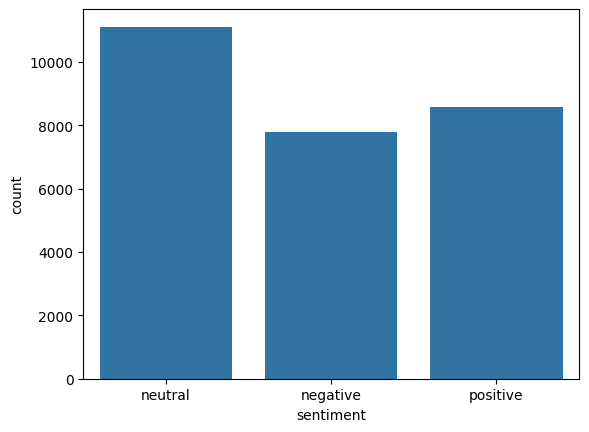

In [ ]:
import seaborn as sns

sns.countplot(x=df['sentiment'])

In [ ]:
df.isna().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0


In [ ]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
df.drop(['textID','selected_text'],axis=1,inplace=True)

In [ ]:
df.head()


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [ ]:
df['sentiment']=df['sentiment'].map({'neutral':0,'negative':-1,'positive':1})

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
0,11117
1,8582
-1,7781


In [44]:
tweet=df.text
tweet

,text
0,"I`d have responded, if I were going"
1,Sooo SAD I will miss you here in San Diego!!!
2,my boss is bullying me...
3,what interview! leave me alone
4,"Sons of ****, why couldn`t they put them on t..."
...,...
27476,wish we could come see u on Denver husband l...
27477,I`ve wondered about rake to. The client has ...
27478,Yay good for both of you. Enjoy the break - y...
27479,But it was worth it ****.


In [45]:
import re

s='a!! ll ap@les a!!@ 1233 o$ranges ##'

# a=re.findall('[^0-9 a-z A-Z]',s)
a=re.findall('[^0-9 a-z A-Z]+',s)     #to remove letters together


a

c=re.sub('[^0-9 a-z A-Z]+','',s)
c

'a ll aples a 1233 oranges '

In [46]:
tweets=tweet.str.replace('[^0-9a-z A-Z]+','',regex=True)
tweets

,text
0,Id have responded if I were going
1,Sooo SAD I will miss you here in San Diego
2,my boss is bullying me
3,what interview leave me alone
4,Sons of why couldnt they put them on the rel...
...,...
27476,wish we could come see u on Denver husband l...
27477,Ive wondered about rake to The client has ma...
27478,Yay good for both of you Enjoy the break you...
27479,But it was worth it


In [47]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wn=WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [48]:
tweets = tweets.apply(lambda x: " ".join([wn.lemmatize(i.lower(), pos='v') for i in x.split()]))
tweets

,text
0,id have respond if i be go
1,sooo sad i will miss you here in san diego
2,my boss be bully me
3,what interview leave me alone
4,sons of why couldnt they put them on the relea...
...,...
27476,wish we could come see u on denver husband los...
27477,ive wonder about rake to the client have make ...
27478,yay good for both of you enjoy the break you p...
27479,but it be worth it


In [49]:
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [50]:
tweets = tweets.apply(lambda x: " ".join([i.lower() for i in x.split() if i not in sw]))
tweets

,text
0,id respond go
1,sooo sad miss san diego
2,boss bully
3,interview leave alone
4,sons couldnt put release already buy
...,...
27476,wish could come see u denver husband lose job ...
27477,ive wonder rake client make clear net dont for...
27478,yay good enjoy break probably need hectic week...
27479,worth


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

X=tfidf.fit_transform(tweets)


In [53]:
X=X.toarray()

In [54]:
import pandas as pd

df1=pd.DataFrame(X)

df1.head()

,0,1,2,3,4,5,6,7,8,9,...,26130,26131,26132,26133,26134,26135,26136,26137,26138,26139
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,df['sentiment'],test_size=0.2,random_state=42)

In [56]:
from sklearn.naive_bayes import MultinomialNB

In [58]:
nb=MultinomialNB()

nb.fit(x_train,y_train)

MultinomialNB()

In [60]:
y_predict=nb.predict(x_test)

In [61]:
from sklearn.metrics import accuracy_score

In [63]:
print(accuracy_score(y_test,y_predict))

0.6148107714701602


In [67]:
new=['this is a good movie']
new=['this is a bad movie']
new=['this is a bad bad movie']

t=tfidf.transform(new)

nb.predict(t)

array([-1])

spam dataset

In [70]:
df=pd.read_csv('/content/spam.csv',encoding='ISO-8859-1')   #nrows specify how many rows : nrows=23

df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [71]:
df['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [72]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [73]:
df.isna().sum()

,0
v1,0
v2,0


In [74]:
text=df['v2']
text

,v2
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [77]:
import re

text=text.str.replace('[^0-9a-z A-Z]+','',regex=True)

text

,v2
0,Go until jurong point crazy Available only in ...
1,Ok lar Joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor U c already then say
4,Nah I dont think he goes to usf he lives aroun...
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will b going to esplanade fr home
5569,Pity was in mood for that Soany other suggest...
5570,The guy did some bitching but I acted like id ...


In [78]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wn=WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [79]:
text=text.apply(lambda x: " ".join([wn.lemmatize(i.lower(), pos='v') for i in x.split()]))
text

,v2
0,go until jurong point crazy available only in ...
1,ok lar joke wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor u c already then say
4,nah i dont think he go to usf he live around h...
...,...
5567,this be the 2nd time we have try 2 contact u u...
5568,will b go to esplanade fr home
5569,pity be in mood for that soany other suggestions
5570,the guy do some bitch but i act like id be int...


In [80]:
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [81]:
tweets = tweets.apply(lambda x: " ".join([i.lower() for i in x.split() if i not in sw]))
tweets

,text
0,id respond go
1,sooo sad miss san diego
2,boss bully
3,interview leave alone
4,sons couldnt put release already buy
...,...
27476,wish could come see u denver husband lose job ...
27477,ive wonder rake client make clear net dont for...
27478,yay good enjoy break probably need hectic week...
27479,worth


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

X=tfidf.fit_transform(text)


In [87]:
X=X.toarray()

In [88]:
import pandas as pd

df1=pd.DataFrame(X)

df1.head()

,0,1,2,3,4,5,6,7,8,9,...,8465,8466,8467,8468,8469,8470,8471,8472,8473,8474
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,df['v1'],test_size=0.2,random_state=42)

In [90]:
from sklearn.naive_bayes import MultinomialNB

nb=MultinomialNB()

nb.fit(x_train,y_train)

MultinomialNB()

In [91]:
y_predict=nb.predict(x_test)

In [92]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_predict))

0.9533632286995516


In [96]:
new=['You are employed']

t=tfidf.transform(new)

nb.predict(t)

array(['ham'], dtype='<U4')